# INSTRUCCIONES

## OBJETIVOS

Desarrollar competencias básicas para:

1. Comprender el perceptrón como modelo fundamental de aprendizaje.
2. Implementar el paso *forward* (predicción) y *backward* (gradientes) de una neurona.
3. Aplicar el algoritmo de **descenso de gradiente** para ajustar pesos.
4. Comparar funciones de activación para clasificación y regresión.
5. Evaluar modelos con métricas apropiadas.
6. Resolver problemas reales simples con un perceptrón y con Keras.
7. Identificar las **limitaciones** del perceptrón.

## ENTREGABLE

*Reglas para el envío de los entregables:*

- **Forma de envío:**

  Este laboratorio se debe enviar únicamente a través de la plataforma [Moodle](https://campusvirtual.escuelaing.edu.co/moodle/) en la actividad definida.

- **Archivo de entrega:**

  Incluyan en un archivo `.zip` los archivos correspondientes al laboratorio, revise **[How to cite in Jupyter Notebooks](https://gist.github.com/ELS4NTA/2c188b3b7300a726e60d71a58a55f740)** para citar cualquier recurso utilizado y ver la estructura del proyecto.

- **Nomenclatura para nombrar el archivo de entrega:**

  El archivo deberá ser renombrado en mayúsculas con el siguiente formato: `L04-{color_grupo}-IAIA-{semestre_academico}.zip`

  Ejemplos:
  ```
  L04-AZUL-IAIA-2026-1.zip
  L04-ROJO-IAIA-2026-1.zip
  ```

## Herramientas del laboratorio

### Bibliotecas conocidas

Ya utilizamos estas bibliotecas en el laboratorio anterior:

- **pandas**: Manipulación y análisis de datos tabulares. [Pandas Documentación](https://pandas.pydata.org/docs/).
- **matplotlib**: Visualización de datos. [Matplotlib Documentación](https://matplotlib.org/stable/).
- **seaborn**: Visualización estadística de alto nivel. [Seaborn Documentación](https://seaborn.pydata.org/).

### Bibliotecas nuevas

En este laboratorio incorporamos:

- **numpy**: Computación numérica con arrays multidimensionales. [Numpy Documentación](https://numpy.org/doc/stable/).
- **TensorFlow / Keras**: Framework de aprendizaje profundo. Keras (incluido en TensorFlow) permite construir y entrenar redes neuronales de forma simplificada. En este laboratorio lo usaremos para construir un modelo equivalente al perceptrón implementado manualmente. [Keras Documentación](https://www.tensorflow.org/api_docs/python/tf/keras).

Revise cuando lo requiera <a href="https://aima.cs.berkeley.edu/global-index.html">(Russell & Norvig, 2021, cap 19, 22) <cite data-cite="russell2021artificial"></cite></a>

In [1]:
# Bibliotecas conocidas
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
    

# Bibliotecas nuevas
import numpy as np

from tensorflow import keras

from tensorflow.keras import layers

# I. COMPRENDIENDO

En esta sección aprenderá los fundamentos matemáticos y de programación necesarios para implementar un perceptrón. Avanzaremos paso a paso: primero las herramientas de NumPy, luego las funciones de activación y pérdida con sus derivadas y métricas asociadas.

## NumPy para Redes Neuronales

NumPy es la base de la computación numérica en Python. Para implementar un perceptrón necesitamos dominar:

- **Vectores y matrices**: representar datos y pesos.
- **Producto punto** (`np.dot`): la operación fundamental de una neurona.
- **Broadcasting**: operaciones entre arrays de distintas dimensiones.
- **Inicialización aleatoria**: para los pesos iniciales.

### Vectores y matrices

Un vector es un array unidimensional. Una matriz es un array bidimensional. En el contexto de redes neuronales:

- Los **datos de entrada** se representan como vectores o matrices.
- Los **pesos** de la neurona son un vector.
- El **sesgo** (*bias*) es un escalar.

In [2]:
# Crear un vector (1D)
x = np.array([1.0, 2.0, 3.0])
print("Vector x:", x)
print("Forma (shape):", x.shape)

# Crear una matriz (2D): 3 ejemplares, 2 características cada uno
X = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])
print("\nMatriz X:")
print(X)
print("Dimension:", X.shape)  # (3, 2) → 3 filas, 2 columnas

Vector x: [1. 2. 3.]
Forma (shape): (3,)

Matriz X:
[[1. 2.]
 [3. 4.]
 [5. 6.]]
Dimension: (3, 2)


### Producto punto

El producto punto es la operación central de una neurona. Dados un vector de pesos $\mathbf{w}$ y un vector de entrada $\mathbf{x}$:

$$z = \mathbf{w} \cdot \mathbf{x} + b = \sum_{i=1}^{n} w_i \cdot x_i + b$$

En NumPy se calcula con `np.dot(w, x)` o equivalentemente `w @ x`.

In [3]:
# Ejemplo: una neurona con 3 entradas
w = np.array([0.5, -0.3, 0.8])    # pesos
x = np.array([1.0, 2.0, 3.0])     # entradas
b = 0.1                           # sesgo (bias)

# Cálculo de la combinación lineal
z = np.dot(w, x) + b
print(f"z = w·x + b = {z}")

# Verificación manual
z_manual = 0.5*1.0 + (-0.3)*2.0 + 0.8*3.0 + 0.1
print(f"Verificación: {z_manual}")

z = w·x + b = 2.4000000000000004
Verificación: 2.4000000000000004


### Broadcasting

Broadcasting permite que NumPy realice operaciones entre arrays de **distintas dimensiones** automáticamente. NumPy "estira" (*broadcast*) el array más pequeño para que coincida con la forma del más grande.

**Regla clave:** Las dimensiones se comparan de derecha a izquierda. Dos dimensiones son compatibles si:

1. Son iguales, o
2. Una de ellas es 1 (o no existe).

Veamos ejemplos concretos de cómo se transforman las dimensiones:

In [4]:
# Ejemplo 1: escalar + vector
# b tiene dimension ()  → se estira a dimension (3,)
# z tiene dimension (3,)
z = np.array([1.0, 2.0, 3.0])    # dimension: (3,)
b = 0.5                          # dimension: ()  → se convierte en [0.5, 0.5, 0.5]
print("z + b =", z + b)
print(f"  Dimensiones: {z.shape} + () → resultado {(z + b).shape}")

# Ejemplo 2: matriz + vector (caso típico en redes neuronales)
# Al calcular z = X ⋅ w + b para múltiples ejemplares:
X = np.array([[1, 2],
              [3, 4],
              [5, 6]])           # dimension: (3, 2) — 3 ejemplares, 2 características
w = np.array([0.5, -0.3])        # dimension: (2,)
b = 0.1                          # dimension: ()

z = np.dot(X, w)        # (3, 2) ⋅ (2,) → (3,)  — un z por cada ejemplo
z_con_b = z + b  # (3,) + ()    → (3,)  — b se suma a cada elemento
print(f"\nX ⋅ w = {z}  dimension: {z.shape}")
print(f"X ⋅ w + b = {z_con_b}  dimension: {z_con_b.shape}")

# Ejemplo 3: broadcasting que NO funciona
try:
    a = np.array([1, 2, 3])     # dimension: (3,)
    c = np.array([1, 2])        # dimension: (2,)
    resultado = a + c           # ¡Error! 3 ≠ 2
except ValueError as e:
    print(f"\nError esperado: {e}")

z + b = [1.5 2.5 3.5]
  Dimensiones: (3,) + () → resultado (3,)

X ⋅ w = [-0.1  0.3  0.7]  dimension: (3,)
X ⋅ w + b = [2.77555756e-17 4.00000000e-01 8.00000000e-01]  dimension: (3,)

Error esperado: operands could not be broadcast together with shapes (3,) (2,) 


### Inicialización aleatoria

Los pesos de una neurona se inicializan con valores aleatorios pequeños. Si todos empiezan en cero, la neurona no puede aprender correctamente.

In [5]:
# Generador de números aleatorios reproducible
rng = np.random.default_rng(42)

# Pesos aleatorios pequeños para 4 entradas
w = rng.standard_normal(4) * 0.01
print("Pesos iniciales:", w)

# Sesgo inicializado en cero
b = 0.0
print("Sesgo inicial:", b)

Pesos iniciales: [ 0.00304717 -0.01039984  0.00750451  0.00940565]
Sesgo inicial: 0.0


### Ejercicio: Operaciones NumPy

1. Cree un vector `x` con 5 elementos aleatorios usando `rng.standard_normal(5)`.
2. Cree un vector de pesos `w` del mismo tamaño, inicializado con valores pequeños (`* 0.01`).
3. Calcule `z = np.dot(w, x) + b` con `b = 0.0`.
4. Verifique que `z` es un escalar. ¿Qué tipo devuelve `type(z)`?
5. Ahora cree una matriz `X` de dimension `(10, 5)` (10 ejemplares, 5 características). Calcule `z = X ⋅ w + b`.
   - ¿Cuál es la dimension del resultado? Explique cómo actúa el broadcasting: `(10, 5) ⋅ (5,) + () → ?`

In [38]:
#1. Crear un vector de 5 entradas aleatorias
x = rng.standard_normal(5)
print(x) 

[-1.4821854  -2.33361612 -0.67826444  0.7494339  -0.28488407]


In [39]:
#2. Crear un vector de 5 pesos aleatorios pequeños
w = rng.standard_normal(5) * 0.01
print(w)

[ 0.0019779   0.01089217  0.01327686 -0.00069138  0.01353586]


In [40]:
#3. Calcular z
b = 0.0
z = np.dot(x, w) + b
print(z)

-0.041729287352222304


In [42]:
#4. Verificar que z es un escalar
type(z)

numpy.float64

In [51]:
X = rng.random((10, 5))
print(X)

z = np.dot(X, w) + b
print(z)

print(f"  Dimensiones: {X.shape} × {w.shape} + () → resultado {(z + b).shape}")

[[0.64914905 0.67020326 0.76290302 0.05810848 0.36660838]
 [0.53952744 0.33845648 0.84447887 0.48257251 0.76862759]
 [0.85201552 0.50479148 0.90955224 0.58712394 0.8502743 ]
 [0.3405908  0.49881696 0.53141104 0.10497972 0.39855251]
 [0.91733767 0.63083224 0.17750658 0.33885564 0.19160301]
 [0.02482313 0.92746046 0.44820733 0.30753507 0.59847719]
 [0.00731446 0.27802211 0.70303347 0.63376977 0.98180595]
 [0.62035771 0.47750587 0.76143256 0.90332787 0.72069595]
 [0.96321122 0.78200517 0.86680144 0.11410407 0.7324135 ]
 [0.4400887  0.5531038  0.65410241 0.96981512 0.98457808]]
[0.02363507 0.02603608 0.03036275 0.0184845  0.0134015  0.02399023
 0.02522822 0.02566821 0.03176623 0.02823598]
  Dimensiones: (10, 5) × (5,) + () → resultado (10,)


Las dimensiones del resultado fueron (10,), se modificaron las dimensiones de w para que quedaran (10,) y se modifico el b para que tambien tenga (10,).

## Funciones de Activación, Pérdida y Métricas

Las funciones de activación determinan **qué tipo de problema** puede resolver la neurona. La función de pérdida mide el error, y la métrica nos dice qué tan bien funciona el modelo. Estos tres conceptos están estrechamente relacionados:

| Tarea | Activación | Pérdida | Métrica |
|-------|-----------|---------|--------|
| **Clasificación** | Sigmoide | Entropía Cruzada Binaria | Accuracy |
| **Regresión** | Identidad | Error Cuadrático Medio | MSE |

Además, para entrenar con descenso de gradiente, necesitamos la **derivada** de cada función.

### Sigmoide: para clasificación

La función sigmoide transforma cualquier valor real en un número entre 0 y 1, lo que permite interpretar la salida como una **probabilidad**.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Su derivada tiene una propiedad muy elegante:

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

Esto significa que podemos calcular la derivada a partir del valor de la función misma.

In [7]:
def sigmoid(z):
    """Función de activación sigmoide."""
    # **COMPLETE**
    pass


def sigmoid_derivative(z):
    """Derivada de la función sigmoide."""
    # **COMPLETE**
    # Pista: usa la función sigmoid() que acabas de implementar
    pass

### Identidad: para regresión

La función identidad simplemente devuelve el valor sin transformar. Se usa cuando queremos que la neurona prediga un **valor numérico** (regresión), no una probabilidad.

$$g(z) = z$$

Su derivada es trivial:

$$g'(z) = 1$$

In [8]:
def identity(z):
    """Función de activación identidad (para regresión)."""
    # **COMPLETE**
    pass


def identity_derivative(z):
    """Derivada de la función identidad."""
    # **COMPLETE**
    pass

### ReLU (Rectified Linear Unit)

ReLU es la función de activación más utilizada en redes neuronales modernas por su simplicidad computacional. No la usaremos directamente en nuestro perceptrón, pero es importante conocerla.

$$\text{ReLU}(z) = \max(0, z)$$

Su derivada es:

$$\text{ReLU}'(z) = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}$$

In [9]:
def relu(z):
    """Función de activación ReLU."""
    # **COMPLETE**
    pass


def relu_derivative(z):
    """Derivada de la función ReLU."""
    # **COMPLETE**
    # Pista: np.where() es útil aquí
    pass

### Ejercicio: Verificar y graficar funciones de activación

1. Verifique sus implementaciones con estos valores:
   - `sigmoid(0)` debe ser `0.5`
   - `identity(3.14)` debe ser `3.14`
   - `relu(-1)` debe ser `0`, `relu(2)` debe ser `2`

2. Grafique las 3 funciones de activación y sus derivadas en una figura con 2 subgráficos (1 fila, 2 columnas):
   - Subgráfico izquierdo: las 3 funciones.
   - Subgráfico derecho: las 3 derivadas.
   - Use `np.linspace(-5, 5, 200)`.

3. Responda:
   - ¿En qué rango de $z$ la derivada de la sigmoide es más grande? ¿Qué implicación tiene para el aprendizaje?
   - ¿Por qué la identidad es adecuada para regresión pero no para clasificación?
   - ¿Qué pasa con la derivada de ReLU cuando $z < 0$?

In [10]:
# **COMPLETE**

### Entropía Cruzada Binaria (BCE): pérdida para clasificación

La BCE penaliza predicciones incorrectas, especialmente las seguras pero equivocadas:

$$\text{BCE} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

Su derivada respecto a $\hat{y}$:

$$\frac{\partial \text{BCE}}{\partial \hat{y}} = -\frac{1}{m} \left( \frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} \right)$$

**Nota:** Se agrega un valor pequeño (`epsilon`) para evitar `log(0)`.

In [11]:
def binary_cross_entropy(y_true, y_pred):
    """Entropía cruzada binaria."""
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    # **COMPLETE**
    pass


def binary_cross_entropy_derivative(y_true, y_pred):
    """Derivada de la entropía cruzada binaria respecto a y_pred."""
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    # **COMPLETE**
    pass

### Error Cuadrático Medio (MSE): pérdida para regresión

Mide el promedio del cuadrado de las diferencias:

$$\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

Su derivada respecto a $\hat{y}$:

$$\frac{\partial \text{MSE}}{\partial \hat{y}} = \frac{-2}{m} (y - \hat{y})$$

In [12]:
def mse(y_true, y_pred):
    """Error cuadrático medio."""
    # **COMPLETE**
    pass


def mse_derivative(y_true, y_pred):
    """Derivada del error cuadrático medio respecto a y_pred."""
    # **COMPLETE**
    pass

### Métricas de evaluación

La pérdida guía el entrenamiento, pero las **métricas** nos dicen qué tan bien funciona el modelo en términos comprensibles:

- **Accuracy** (clasificación): proporción de predicciones correctas.

$$\text{Accuracy} = \frac{\text{predicciones correctas}}{\text{total de predicciones}}$$

- **MSE** ya sirve como métrica para regresión (valores más bajos = mejor).

In [13]:
def accuracy(y_true, y_pred):
    """Accuracy para clasificación."""
    # **COMPLETE**
    pass


def precision(y_true, y_pred):
    """Precisión: de los predichos positivos, cuántos lo son realmente."""
    # **COMPLETE**
    # TP = sum((y_true == 1) & (y_pred == 1))
    # FP = sum((y_true == 0) & (y_pred == 1))
    pass

### Ejercicio: Verificar funciones de pérdida y métricas

1. Verifique con estos datos de clasificación:
   ```python
   y_true = np.array([1, 0, 1, 1])
   y_pred_prob = np.array([0.9, 0.1, 0.8, 0.7])  # probabilidades
   y_pred_bin = (y_pred_prob >= 0.5).astype(int)   # predicciones binarias
   ```
   - Calcule BCE y accuracy.

2. Verifique con datos de regresión:
   ```python
   y_true_reg = np.array([3.0, 5.0, 2.5, 7.0])
   y_pred_reg = np.array([2.8, 5.2, 2.3, 6.5])
   ```
   - Calcule MSE.

3. Grafique cómo cambia BCE cuando `y_true = 1` y `y_pred` varía de 0.01 a 0.99. ¿Qué observa?

In [14]:
# **COMPLETE**

# II. PERCEPTRÓN CON DESCENSO DE GRADIENTE

Ahora que tenemos las herramientas matemáticas, vamos a construir un **perceptrón** (una sola neurona artificial) que aprende usando **descenso de gradiente**.

## Paso Forward: La predicción

El paso forward calcula la predicción de la neurona en dos etapas:

**Etapa 1: Combinación lineal**

$$z = \mathbf{w} \cdot \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

**Etapa 2: Activación**

$$\hat{y} = g(z)$$

donde $g$ es la función de activación:

- $g = \sigma$ (sigmoide) para clasificación → $\hat{y} \in (0, 1)$
- $g = \text{identidad}$ para regresión → $\hat{y} \in (-\infty, +\infty)$

Para múltiples ejemplares (matriz $X$ de dimension $m \times n$):

$$\mathbf{z} = X \mathbf{w} + b \quad\text{dimension: } (m,n) \times (n,) + () \to (m,)$$
$$\hat{\mathbf{y}} = g(\mathbf{z}) \quad\text{dimension: } (m,)$$

## Paso Backward: Pérdida y Descenso de Gradiente

El paso backward tiene dos objetivos:

1. **Calcular la pérdida** $\mathcal{L}$ que mide el error.
2. **Calcular los gradientes** para saber cómo ajustar los pesos.

### Cálculo de la pérdida

$$\mathcal{L} = \text{Loss}(y, \hat{y})$$

### Descenso de gradiente (regla de la cadena)

Queremos saber: ¿cuánto cambia $\mathcal{L}$ si cambio cada peso $w_i$?

$$\frac{\partial \mathcal{L}}{\partial w_i} = \underbrace{\frac{\partial \mathcal{L}}{\partial \hat{y}}}_{\text{derivada de la pérdida}} \cdot \underbrace{\frac{\partial \hat{y}}{\partial z}}_{\text{derivada de la activación}} \cdot \underbrace{\frac{\partial z}{\partial w_i}}_{= x_i}$$

Para el sesgo:
$$\frac{\partial \mathcal{L}}{\partial b} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \underbrace{\frac{\partial z}{\partial b}}_{= 1}$$

### Actualización de parámetros

Finalmente, ajustamos los pesos en la dirección que **reduce** la pérdida:

$$w_i \leftarrow w_i - \alpha \cdot \frac{\partial \mathcal{L}}{\partial w_i}$$
$$b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

donde $\alpha$ es el **learning rate** (tasa de aprendizaje).

## Implementación del Perceptrón

Complete la siguiente implementación. Cada método corresponde a un paso del proceso:

- `forward` → paso forward
- `compute_loss` → calcular la pérdida
- `backward` → calcular gradientes
- `update_parameters` → actualizar pesos
- `train` → repetir el ciclo por épocas
- `predict` → generar predicciones

In [15]:
class Perceptron:
    """Una sola neurona con descenso de gradiente."""

    def __init__(self, n_features, activation="sigmoid", loss="bce", learning_rate=0.01):
        """Inicializar pesos, sesgo y configuración."""
        rng = np.random.default_rng(42)
        self.weights = rng.standard_normal(n_features) * 0.01
        self.bias = 0.0
        self.learning_rate = learning_rate

        # Funciones de activación
        activations = {
            "sigmoid": (sigmoid, sigmoid_derivative),
            "identity": (identity, identity_derivative),
            "relu": (relu, relu_derivative),
        }
        self.activation_fn, self.activation_deriv = activations[activation]

        # Funciones de pérdida
        losses = {
            "bce": (binary_cross_entropy, binary_cross_entropy_derivative),
            "mse": (mse, mse_derivative),
        }
        self.loss_fn, self.loss_deriv = losses[loss]

        self.loss_history = []

    def forward(self, X):
        """Calcular predicción: z = X ⋅ w + b, luego activación."""
        # **COMPLETE**
        self.z = None      # Guardar para el backward
        self.y_pred = None  # Guardar para el backward
        return self.y_pred

    def compute_loss(self, y_true, y_pred):
        """Calcular la pérdida."""
        # **COMPLETE**
        pass

    def backward(self, X, y_true):
        """Calcular gradientes usando la regla de la cadena.

        dL/dw = dL/dy_pred * dy_pred/dz * dz/dw
        dL/db = dL/dy_pred * dy_pred/dz * dz/db
        """
        m = X.shape[0]

        # 1. Derivada de la pérdida respecto a y_pred
        # **COMPLETE**
        dL_dy = None

        # 2. Derivada de la activación respecto a z
        # **COMPLETE**
        dy_dz = None

        # 3. Combinar: delta = dL/dy * dy/dz  (regla de la cadena)
        # **COMPLETE**
        delta = None  # dimension (m,)

        # 4. Gradientes de w y b
        # dw = (1/m) * X^T ⋅ delta
        # db = (1/m) * sum(delta)
        # **COMPLETE**
        self.dw = None
        self.db = None

    def update_parameters(self):
        """Actualizar pesos con descenso de gradiente."""
        # **COMPLETE**
        # w = w - lr * dw
        # b = b - lr * db
        pass

    def train(self, X, y, epochs=100, verbose=True):
        """Entrenar el perceptrón por épocas."""
        self.loss_history = []

        for epoch in range(epochs):
            # Forward
            # **COMPLETE**

            # Backward: pérdida + gradientes + actualización
            # **COMPLETE**

            self.loss_history.append(loss)
            if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
                print(f"Época {epoch:>5d}/{epochs} — Pérdida: {loss:.6f}")

        return self.loss_history

    def predict(self, X, threshold=0.5):
        """Predicciones binarias (para clasificación)."""
        y_prob = self.forward(X)
        # **COMPLETE**
        pass

## Entrenamiento con datos sintéticos

Antes de usar datos reales, verifiquemos que la implementación funciona con un dataset simple.

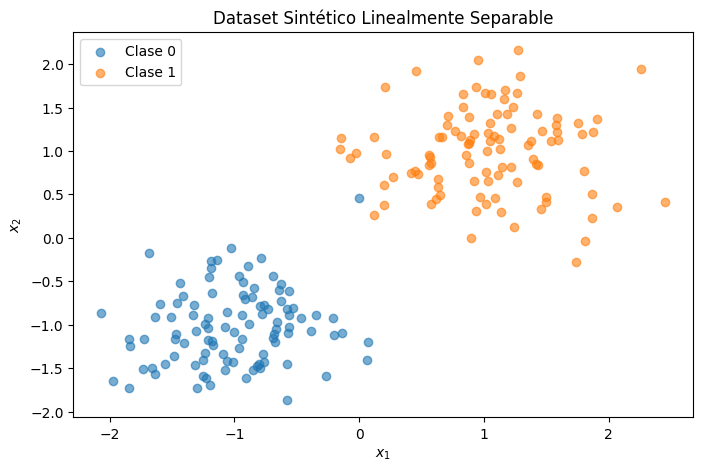

In [16]:
# Generar dataset sintético linealmente separable
rng = np.random.default_rng(42)
m = 200  # número de ejemplares

# Clase 0: centrada en (-1, -1)
X_0 = rng.standard_normal((m // 2, 2)) * 0.5 + np.array([-1, -1])
# Clase 1: centrada en (1, 1)
X_1 = rng.standard_normal((m // 2, 2)) * 0.5 + np.array([1, 1])

X_synth = np.vstack([X_0, X_1])
y_synth = np.array([0] * (m // 2) + [1] * (m // 2), dtype=float)

# Visualizar
plt.figure(figsize=(8, 5))
plt.scatter(X_synth[y_synth == 0, 0], X_synth[y_synth == 0, 1], label="Clase 0", alpha=0.6)
plt.scatter(X_synth[y_synth == 1, 0], X_synth[y_synth == 1, 1], label="Clase 1", alpha=0.6)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Dataset Sintético Linealmente Separable")
plt.legend()
plt.show()

### Ejercicio: Entrenar y evaluar con datos sintéticos

1. Cree un perceptrón con `n_features=2`, activación `"sigmoid"`, pérdida `"bce"` y `learning_rate=0.1`.
2. Entrene durante 500 épocas.
3. Grafique la evolución de la pérdida.
4. Calcule el accuracy: `accuracy(y_synth, perceptron.predict(X_synth))`.
5. ¿El modelo converge?

In [17]:
# **COMPLETE**

### Ejercicio: Visualizar la frontera de decisión

La frontera de decisión es la línea donde $\hat{y} = 0.5$, es decir, $z = 0$:

$$w_1 x_1 + w_2 x_2 + b = 0 \implies x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$

Grafique los datos y la frontera de decisión superpuesta.

In [18]:
# **COMPLETE**

### Ejercicio: Experimentar con learning rate

Entrene con los siguientes learning rates y grafique sus curvas de pérdida **en un solo gráfico**:

- `0.001` (muy bajo)
- `0.01`
- `0.1`
- `1.0` (muy alto)

Responda:

- ¿Qué pasa con un learning rate muy bajo?
- ¿Qué pasa con un learning rate muy alto?
- ¿Cuál es el mejor para este problema?

In [19]:
# **COMPLETE**

# III. APLICANDO EL PERCEPTRÓN

Apliquemos el perceptrón al dataset **Titanic** <cite data-cite="titanic2012"></cite> para predecir si un pasajero sobrevivió.

![titanic](./images/titanic.png)

## Carga y exploración

In [20]:
df = pd.read_csv("data/titanic.csv")
print(f"Forma del dataset: {df.shape}")
df.head()

Forma del dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## Preprocesamiento

El perceptrón requiere datos **numéricos** y **sin valores faltantes**. Además, es recomendable **normalizar** las características.

**Pasos:**

1. Seleccionar características numéricas relevantes.
2. Manejar datos faltantes.
3. Normalizar con min-max: $x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$

In [22]:
# Seleccionar características y variable objetivo
features = ["pclass", "age", "sibsp", "parch", "fare"]
df["is_male"] = df["adult_male"].astype(int)
features.append("is_male")

# Eliminar filas con datos faltantes
df_clean = df[features + ["survived"]].dropna()
print(f"Filas después de limpieza: {len(df_clean)} (eliminadas: {len(df) - len(df_clean)})")

# Separar X e y
X_titanic = df_clean[features].values
y_titanic = df_clean["survived"].values.astype(float)

print(f"Forma de X: {X_titanic.shape}")
print(f"Distribución: {np.mean(y_titanic):.2%} sobrevivieron")

Filas después de limpieza: 714 (eliminadas: 177)
Forma de X: (714, 6)
Distribución: 40.62% sobrevivieron


### Ejercicio: Normalizar y entrenar

1. Normalice `X_titanic` con min-max.
2. Cree un perceptrón con activación `"sigmoid"`, pérdida `"bce"` y `learning_rate=0.1`.
3. Entrene durante 1000 épocas.
4. Grafique la curva de pérdida.
5. Calcule accuracy y precision.

In [23]:
# **COMPLETE**

### Ejercicio: Analizar los pesos

1. Grafique los pesos del perceptrón como un gráfico de barras, usando los nombres de las características.
2. ¿Qué característica tiene mayor peso (en valor absoluto)? ¿Tiene sentido?
3. ¿Qué pasa si **no normaliza** los datos? Pruébelo y explique.

In [24]:
# **COMPLETE**

# IV. USANDO KERAS

Ahora que entendemos cómo funciona un perceptrón internamente, usaremos **Keras** para construir el mismo modelo de forma simplificada.

## Mini tutorial de Keras

Keras usa un flujo de trabajo en 4 pasos:

### Definir el modelo

`Sequential` permite apilar capas. `Dense` es una capa completamente conectada. Con **1 neurona Dense + sigmoide** creamos exactamente un perceptrón:

```python
model = keras.Sequential([
    layers.Dense(units=1, activation="sigmoid", input_shape=(n_features,))
])
```

### Compilar

Especificar pérdida, optimizador y métricas:

```python
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
```

- `SGD` = Descenso de Gradiente Estocástico (el mismo algoritmo que implementamos).
- `binary_crossentropy` = la misma BCE.

### Entrenar

```python
history = model.fit(X, y, epochs=100)
```

`fit()` hace internamente: forward → pérdida → backward → actualización.

### Evaluar

```python
loss, acc = model.evaluate(X, y)
predictions = model.predict(X)
```

## Perceptrón equivalente en Keras

Resuelva el mismo problema del Titanic.

In [25]:
# Paso 1: Definir — un perceptrón es una capa Dense con 1 neurona
# **COMPLETE**
# model = keras.Sequential([
#     layers.Dense(...)
# ])

In [26]:
# Paso 2: Compilar con SGD, binary_crossentropy, accuracy
# **COMPLETE**

In [27]:
# Paso 3: Entrenar 1000 épocas con los datos normalizados
# **COMPLETE**
# history = model.fit(...)

In [28]:
# Paso 4: Evaluar
# **COMPLETE**
# loss, acc = model.evaluate(...)

### Ejercicio: Comparar manual vs Keras

1. Grafique las curvas de pérdida de ambos modelos en un solo gráfico.
2. Extraiga los pesos de Keras: `weights, bias = model.layers[0].get_weights()`. Compárelos con los de su modelo manual.
3. Compare el accuracy de ambos modelos.

In [29]:
# **COMPLETE**

## Reflexión: Manual vs Keras

Responda:

1. **¿Qué hace Keras automáticamente** que usted tuvo que implementar a mano?

2. **¿Dónde está el cálculo del gradiente** en el código de Keras? ¿Lo ve explícitamente?

3. **¿Qué se gana** al usar Keras? (productividad, optimización...)

4. **¿Qué se pierde** al usar Keras? (comprensión interna, control...)

5. **¿Coinciden los resultados?** ¿Por qué podrían diferir?

In [30]:
# **COMPLETE**

# V. LIMITACIONES DEL PERCEPTRÓN

El perceptrón es un **clasificador lineal**: solo puede separar clases con una línea recta (o hiperplano). Esto significa que existen problemas que **no puede resolver**.

En esta sección vamos a:

1. Visualizar un dataset donde las clases **se solapan** y no son linealmente separables.
2. Observar cómo el perceptrón **falla**.

## Dataset: Palmer Penguins <cite data-cite="palmerpenguins"></cite>

Vamos a intentar clasificar dos especies de pingüinos (**Adelie** y **Chinstrap**) usando las dimensiones de su pico. Estas dos especies tienen características que se **solapan** significativamente, haciendo el problema difícil para un clasificador lineal.

![palmerpenguins](./images/palmerpenguins.png)

In [31]:
# Cargar y preparar datos de pingüinos
penguins = pd.read_csv("data/penguins.csv")

# Filtrar solo Adelie y Chinstrap
mask = penguins["species"].isin(["Adelie", "Chinstrap"])
df_peng = penguins[mask][["species", "bill_length_mm", "bill_depth_mm"]].dropna()

print(f"Total: {len(df_peng)} pingüinos")
print(df_peng["species"].value_counts())

Total: 219 pingüinos
species
Adelie       151
Chinstrap     68
Name: count, dtype: int64


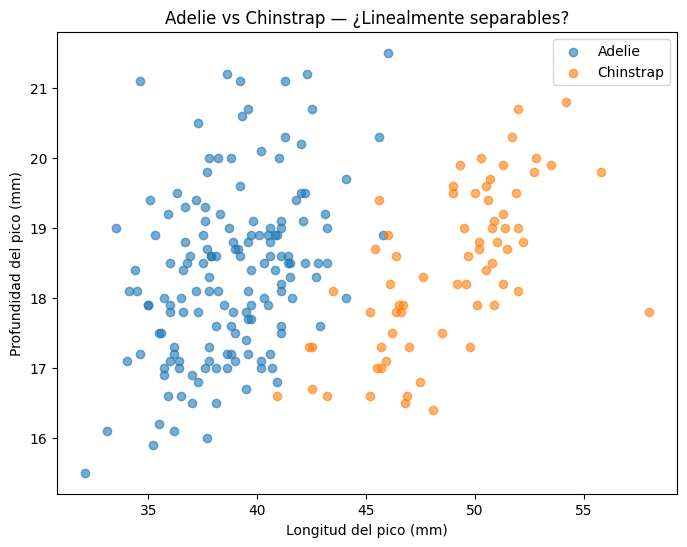

In [32]:
# Visualizar: ¿son linealmente separables?
plt.figure(figsize=(8, 6))
for species, color in [("Adelie", "tab:blue"), ("Chinstrap", "tab:orange")]:
    subset = df_peng[df_peng["species"] == species]
    plt.scatter(subset["bill_length_mm"], subset["bill_depth_mm"],
               label=species, alpha=0.6, color=color)

plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Profundidad del pico (mm)")
plt.title("Adelie vs Chinstrap — ¿Linealmente separables?")
plt.legend()
plt.show()

### Ejercicio: Observar el solapamiento

1. Observe el gráfico. ¿Puede trazar una línea recta que separe perfectamente ambas especies?
2. ¿En qué zona del gráfico se solapan las clases?

## El perceptrón intenta (y falla)

Intentemos clasificar con nuestro perceptrón.

In [33]:
# Preparar datos
X_peng = df_peng[["bill_length_mm", "bill_depth_mm"]].values
y_peng = (df_peng["species"] == "Chinstrap").astype(float).values

# Normalizar
X_peng_norm = (X_peng - X_peng.min(axis=0)) / (X_peng.max(axis=0) - X_peng.min(axis=0))

### Ejercicio: Entrenar el perceptrón con pingüinos

1. Cree un perceptrón con `sigmoid` + `bce`, learning_rate=0.1.
2. Entrene durante 1000 épocas.
3. Calcule accuracy.
4. Grafique la frontera de decisión sobre los datos.
5. ¿Qué accuracy obtiene? ¿Es suficiente?

In [34]:
# **COMPLETE**

## Reflexión: ¿Por qué falla el perceptrón?

Responda:

1. ¿Por qué el perceptrón no puede clasificar bien las dos especies de pingüinos?

2. ¿Qué tipo de frontera de decisión traza el perceptrón?

3. ¿La red multicapa resuelve el problema perfectamente? Si no, ¿por qué?

4. ¿Qué relación tiene esto con el famoso **problema XOR**, que Minsky y Papert demostraron en 1969 que un perceptrón simple no puede resolver?

In [35]:
# **COMPLETE**

# VI. RETROSPECTIVA

Responda las siguientes preguntas de forma individual y como equipo:

1. ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

2. ¿Cuál es el estado actual del laboratorio? ¿Por qué?

3. ¿Cuál consideran fue el mayor logro? ¿Por qué?

4. ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

5. ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

In [36]:
# **COMPLETE**